# Lidar–VectorNav Sync Workbench

This notebook starts the implementation of per-window timing-offset estimation for lidar vertical stares against continuous VectorNav `VelNED2`.

The initial implementation covers:

- project setup and shared imports
- cached lidar chunk/file bookkeeping
- periodic beam buffers and single-file reads
- chunk extraction with the existing `fit_offset` prior
- mdv-based sync signal construction using the `1.03` intensity threshold
- FFT bandpass filtering, analytic-envelope construction, and FFT cross-correlation
- one-window diagnostics for coarse and fine timing estimates

Later cells can extend this to multi-window continuity priors, jump detection, and production integration.

In [1]:
# preamble
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Printf
using Statistics
using FFTW
using PyPlot
using NCDatasets

includet("./lidar_vn_sync.jl")
using .LidarVNSync

ctx = LidarVNSync.setup_sync_context()
Env = ctx.Env
Vn = ctx.Vn
UV = ctx.UV
beams = ctx.beams
icvn = ctx.icvn
nz = ctx.nz

  Activating project at `~/Projects/lidar/ASTRAL2024`


80

In [2]:
# notebook workflow functions

function process_lidar_vn_data(; mode=:test, test_ic=175:190, ntop=nz)
    ic_list = mode == :all ? collect(icvn) : collect(test_ic)
    # UV is passed through the shared reader for compatibility and later motion correction.
    # The sync offsets computed here are fit only from mdv and vn2.
    result = LidarVNSync.process_sync_data(
        beams,
        Env,
        Vn,
        UV,
        ic_list;
        ntop=ntop,
    )
    return result
end

function save_sync_data_netcdf(result; nc_out=joinpath("epsilon_data", "vn_sync_offsets.nc"))
    return LidarVNSync.save_sync_netcdf(result; nc_out=nc_out)
end

function run_sync_diagnostics(result; mode=:test, single_ic=nothing, ntop=nz)
    fig_offsets = LidarVNSync.diagnostic_offsets(result)

    fig_single = nothing
    if mode == :test
        ic = isnothing(single_ic) ? result.seq_ic[1] : single_ic
        single = LidarVNSync.diagnostic_single_window(beams, Env, Vn, UV, ic; ntop=ntop)
        fig_single = single.fig
    end

    return (; fig_offsets, fig_single)
end

read_synced_motion_data(nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc")) =
    LidarVNSync.read_synced_motion(nc_path)

motion_correct_stare(dopplervel, nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc"); record_inds=:) =
    LidarVNSync.read_and_motion_correct_stare(dopplervel, nc_path; record_inds=record_inds)

motion_correct_stare (generic function with 2 methods)

chunk,offset_s,corr_sync,coherency_5_20s,is_synced,is_failed
200,-0.1,0.7549372568023127,0.9536933844529086,true,false
430,-0.020000000000000018,-0.049855464351938626,0.15441551920804214,false,false
431,-3.04,-0.03768725406401165,0.1559316203363983,false,false
432,-2.1292857142857144,0.014047397854515416,0.1518623883347091,false,false

Summary
valid chunks: 4 / 4
synced windows: 1
failed windows: 0
offset_s min/median/max: -3.04 / -1.1146428571428573 / -0.020000000000000018
corr_sync median: -0.011819928104748115
coherency_5_20s median: 0.15517356977222022
failed ranges: none
Saved metrics CSV: epsilon_data/vn_sync_metrics_chunks_200_500.csv
Saved text output: lidar_vn_sync_workbench_shortTestOutput.txt

Example picks
(chunk, actual_s)
(200, -0.1)
(430, -0.020000000000000018)
(431, -3.04)
(432, -2.1292857142857144)
Saved plot: epsilon_data/vn_sync_examples_offsets_0_2_5_10s_with_quality.png


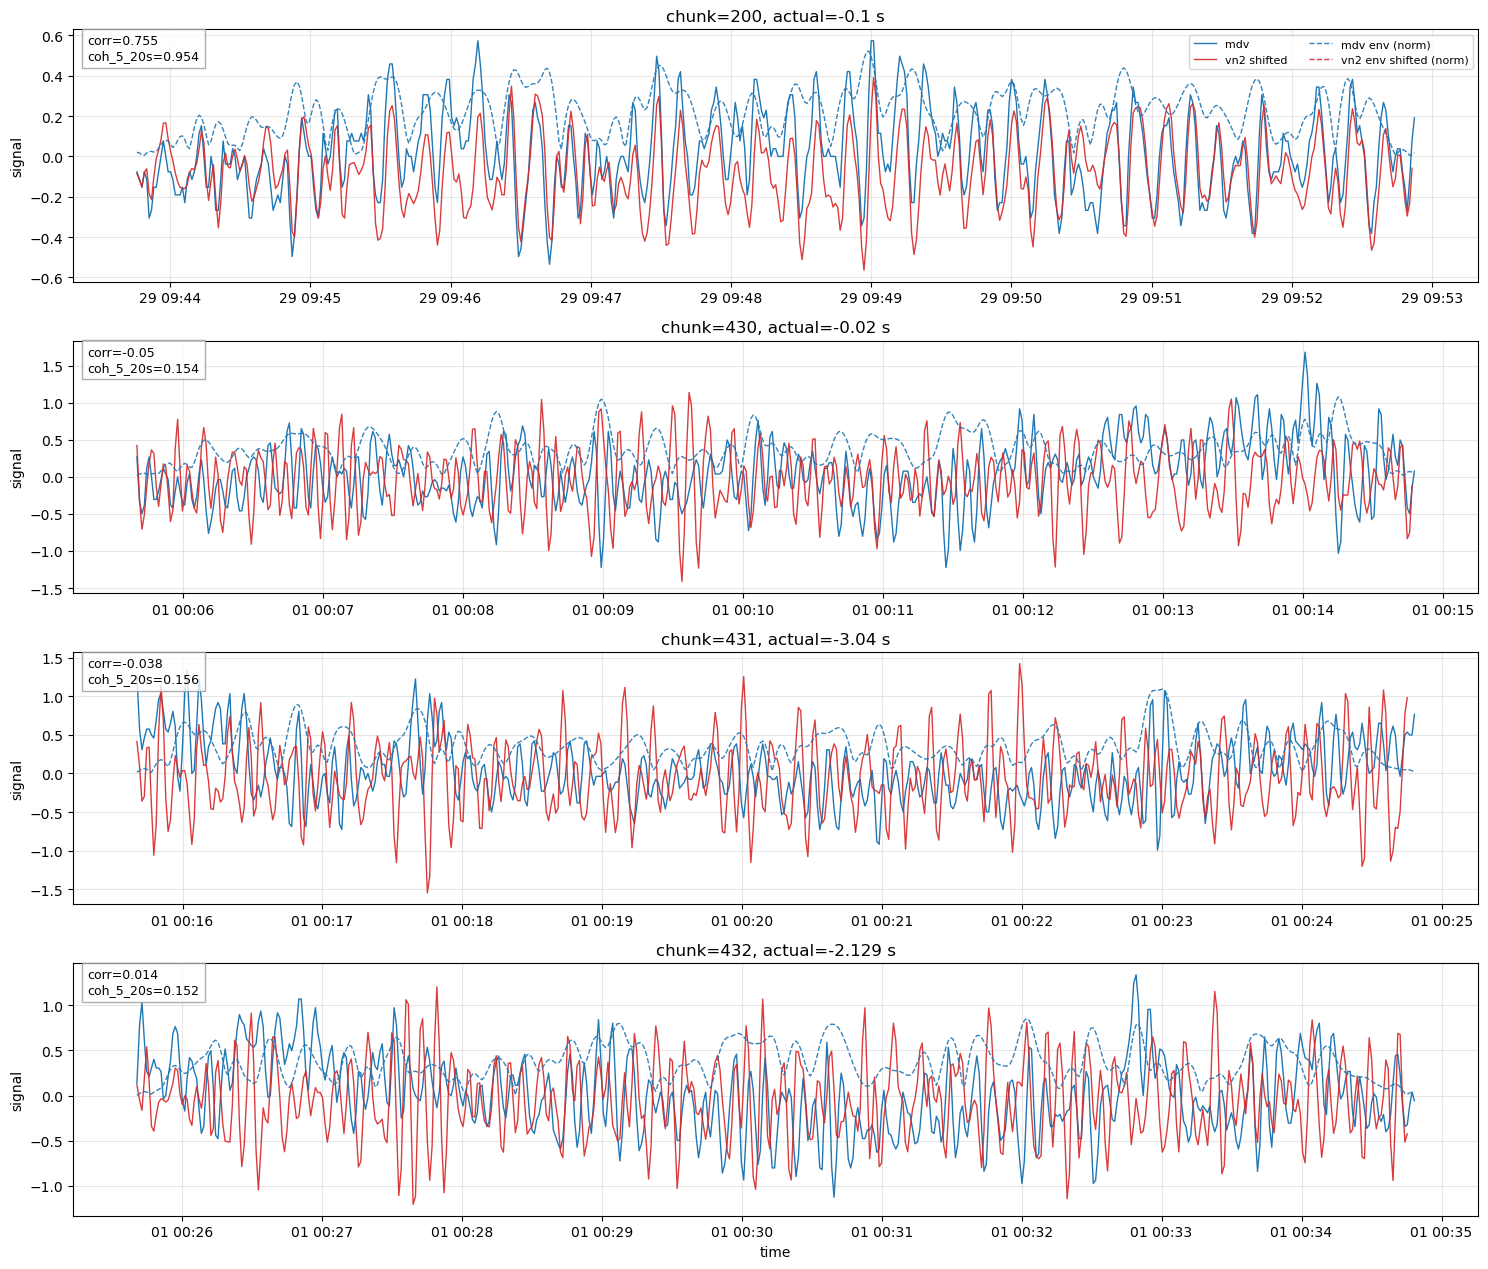

In [3]:
# TEST: Chunks 200:500 offset sweep with sync-quality metrics.
# Interpretation used in this test:
# - synced window:   corr_sync >= 0.75 and coherency_5_20s >= 0.95
# - failed syncing:  corr_sync <  0.05 and coherency_5_20s <  0.15

function pearson_finite(x, y)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 4 && return NaN
    sx = std(xv)
    sy = std(yv)
    (!isfinite(sx) || !isfinite(sy) || sx == 0 || sy == 0) && return NaN
    return cor(xv, yv)
end

function band_coherence_welch_5_20s(x, y; dt=1.0, flo=1 / 20, fhi=1 / 5)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 48 && return NaN

    nseg = min(128, n)
    nseg < 32 && return NaN
    step = max(8, nseg ÷ 2)

    win = 0.5 .- 0.5 .* cos.(2pi .* (0:(nseg - 1)) ./ (nseg - 1))

    nfreq = div(nseg, 2) + 1
    Sxx = zeros(Float64, nfreq)
    Syy = zeros(Float64, nfreq)
    Sxy = zeros(ComplexF64, nfreq)
    k = 0

    for i0 in 1:step:(n - nseg + 1)
        xs = xv[i0:(i0 + nseg - 1)]
        ys = yv[i0:(i0 + nseg - 1)]

        xs .-= mean(xs)
        ys .-= mean(ys)

        X = FFTW.rfft(xs .* win)
        Y = FFTW.rfft(ys .* win)

        Sxx .+= abs2.(X)
        Syy .+= abs2.(Y)
        Sxy .+= X .* conj.(Y)
        k += 1
    end

    k == 0 && return NaN
    Sxx ./= k
    Syy ./= k
    Sxy ./= k

    coh = abs2.(Sxy) ./ (Sxx .* Syy .+ eps())
    fs = 1 / dt
    freq = collect(0:div(nseg, 2)) .* (fs / nseg)
    band = (freq .>= flo) .& (freq .<= fhi)
    any(band) || return NaN

    c = coh[band]
    c = c[isfinite.(c)]
    isempty(c) && return NaN
    return mean(c)
end

function contiguous_ranges(mask::AbstractVector{Bool}, labels::AbstractVector)
    ranges = Tuple{eltype(labels), eltype(labels)}[]
    i = 1
    n = length(mask)
    while i <= n
        if !mask[i]
            i += 1
            continue
        end
        i0 = i
        while i <= n && mask[i]
            i += 1
        end
        i1 = i - 1
        push!(ranges, (labels[i0], labels[i1]))
    end
    return ranges
end

function run_offset_quality_test(run_test::Bool; 
    test_chunks=200:500, targets_s=[0.0, 2.0, 5.0, 10.0], ntop=nz, 
    sync_corr_thr=0.5, sync_coh_thr=0.9, fail_corr_thr=0.1, fail_coh_thr=0.15)
    
    if !run_test
        println("Set run_test=true to execute for chunks $(first(test_chunks)):$(last(test_chunks)).")
        return nothing
    end

    sync_result = process_lidar_vn_data(; mode=:test, test_ic=test_chunks, ntop=ntop)
    seq_ic = sync_result.seq_ic
    offset_s = Float64.(sync_result.seq_final_native)
    valid = isfinite.(offset_s) .& (offset_s .!= LidarVNSync.OFFSET_SENTINEL_S)

    corr_sync = fill(NaN, length(seq_ic))
    coherency_5_20s = fill(NaN, length(seq_ic))

    state_metrics = LidarVNSync.init_stream_state()
    for i in eachindex(seq_ic)
        valid[i] || continue

        ic = seq_ic[i]
        t_shift = offset_s[i]

        win = LidarVNSync.extract_sync_window(beams, Env, state_metrics, Vn, UV, ic; ntop=ntop, nc_dir="./data/netcdf_stare")
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        vn2_sync = LidarVNSync.shift_signal_linear(win.vn2_xcorr, t_shift; dt=dt1)
        corr_sync[i] = pearson_finite(win.mdv, vn2_sync)
        coherency_5_20s[i] = band_coherence_welch_5_20s(win.mdv, vn2_sync; dt=dt1)
    end

    is_synced = valid .& (corr_sync .>= sync_corr_thr) .& (coherency_5_20s .>= sync_coh_thr)
    is_failed = valid .& (corr_sync .< fail_corr_thr) .& (coherency_5_20s .< fail_coh_thr)

    println("chunk,offset_s,corr_sync,coherency_5_20s,is_synced,is_failed")
    for i in eachindex(seq_ic)
        println("$(seq_ic[i]),$(offset_s[i]),$(corr_sync[i]),$(coherency_5_20s[i]),$(is_synced[i]),$(is_failed[i])")
    end

    println("\nSummary")
    println("valid chunks: $(count(valid)) / $(length(valid))")
    println("synced windows: $(count(is_synced))")
    println("failed windows: $(count(is_failed))")

    if any(valid)
        vo = offset_s[valid]
        vc = corr_sync[valid]
        vh = coherency_5_20s[valid]
        println("offset_s min/median/max: $(minimum(vo)) / $(median(vo)) / $(maximum(vo))")
        vcf = vc[isfinite.(vc)]
        vhf = vh[isfinite.(vh)]
        isempty(vcf) || println("corr_sync median: $(median(vcf))")
        isempty(vhf) || println("coherency_5_20s median: $(median(vhf))")
    end

    fail_ranges = contiguous_ranges(is_failed, seq_ic)
    if isempty(fail_ranges)
        println("failed ranges: none")
    else
        println("failed ranges (chunk_start, chunk_end):")
        for r in fail_ranges
            println(r)
        end
    end

    mkpath("epsilon_data")
    metrics_csv = joinpath("epsilon_data", "vn_sync_metrics_chunks_200_500.csv")
    open(metrics_csv, "w") do io
        println(io, "chunk,offset_s,corr_sync,coherency_5_20s,is_synced,is_failed")
        for i in eachindex(seq_ic)
            println(io, "$(seq_ic[i]),$(offset_s[i]),$(corr_sync[i]),$(coherency_5_20s[i]),$(is_synced[i]),$(is_failed[i])")
        end
    end

    short_txt = "lidar_vn_sync_workbench_shortTestOutput.txt"
    open(short_txt, "w") do io
        println(io, "chunk,offset_s,corr_sync,coherency_5_20s,is_synced,is_failed")
        for i in eachindex(seq_ic)
            println(io, "$(seq_ic[i]),$(offset_s[i]),$(corr_sync[i]),$(coherency_5_20s[i]),$(is_synced[i]),$(is_failed[i])")
        end
        println(io)
        println(io, "failed_ranges")
        for r in fail_ranges
            println(io, "$(r[1]),$(r[2])")
        end
    end
    println("Saved metrics CSV: ", metrics_csv)
    println("Saved text output: ", short_txt)

    idx_valid = findall(valid)
    isempty(idx_valid) && error("No valid offsets found for chunks $(first(test_chunks)):$(last(test_chunks))")

    ic_valid = seq_ic[idx_valid]
    off_valid = offset_s[idx_valid]

    use_targets = eltype(targets_s) <: Real
    if use_targets
        pick = [argmin(abs.(off_valid .- t)) for t in targets_s]
        example_ic = ic_valid[pick]
        example_shift_s = off_valid[pick]
    else
        example_ic = ic_valid
        example_shift_s = off_valid
    end

    println("\nExample picks")
    if use_targets
        println("(target_s, chunk, actual_s)")
        for i in eachindex(targets_s)
            println((targets_s[i], example_ic[i], example_shift_s[i]))
        end
    else
        println("(chunk, actual_s)")
        for i in eachindex(example_ic)
            println((example_ic[i], example_shift_s[i]))
        end
    end

    nplots = length(example_ic)
    fig, axs = subplots(nplots, 1, figsize=(15, 3.2 * nplots), sharex=false)
    nplots == 1 && (axs = [axs])
    state_plot = LidarVNSync.init_stream_state()

    for i in 1:nplots
        ic = example_ic[i]
        t_shift = example_shift_s[i]

        win = LidarVNSync.extract_sync_window(beams, Env, state_plot, Vn, UV, ic; ntop=ntop, nc_dir="./data/netcdf_stare")
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        vn2_sync = LidarVNSync.shift_signal_linear(win.vn2_xcorr, t_shift; dt=dt1)

        mdv_bp = LidarVNSync.fft_bandpass(win.mdv; dt=dt1)
        vn2_bp = LidarVNSync.fft_bandpass(vn2_sync; dt=dt1)
        mdv_env = LidarVNSync.analytic_envelope_fft(mdv_bp)
        vn2_env = LidarVNSync.analytic_envelope_fft(vn2_bp)

        finite_env = isfinite.(mdv_env) .& isfinite.(vn2_env)
        env_scale = any(finite_env) ? maximum(abs, vcat(mdv_env[finite_env], vn2_env[finite_env])) : 1.0
        env_scale == 0 && (env_scale = 1.0)
        mdv_env_n = mdv_env ./ env_scale
        vn2_env_n = vn2_env ./ env_scale

        c = pearson_finite(win.mdv, vn2_sync)
        h = band_coherence_welch_5_20s(win.mdv, vn2_sync; dt=dt1)

        ax = axs[i]
        ax.plot(win.stare_dt, win.mdv, color="#1f77b4", linewidth=1.0, label="mdv")
        ax.plot(win.stare_dt, vn2_sync, color="#d62728", linewidth=1.0, alpha=0.9, label="vn2 shifted")
        ax.plot(win.stare_dt, mdv_env_n, color="#1f77b4", linestyle="--", linewidth=1.0, alpha=0.9, label="mdv env (norm)")
        ax.plot(win.stare_dt, vn2_env_n, color="#d62728", linestyle="--", linewidth=1.0, alpha=0.9, label="vn2 env shifted (norm)")
        ax.grid(true, alpha=0.3)
        ax.set_ylabel("signal")

        if use_targets
            t_target = targets_s[i]
            ax.set_title("target=$(round(t_target, digits=1)) s, chunk=$(ic), actual=$(round(t_shift, digits=3)) s")
        else
            ax.set_title("chunk=$(ic), actual=$(round(t_shift, digits=3)) s")
        end

        txt = "corr=$(round(c, digits=3))\ncoh_5_20s=$(round(h, digits=3))"
        ax.text(0.01, 0.98, txt, transform=ax.transAxes, va="top", ha="left", bbox=Dict("facecolor"=>"white", "alpha"=>0.8, "edgecolor"=>"0.6"), fontsize=9)

        if i == 1
            ax.legend(loc="upper right", ncol=2, fontsize=8)
        end
        if i == nplots
            ax.set_xlabel("time")
        end
    end

    tight_layout()
    plot_path = joinpath("epsilon_data", "vn_sync_examples_offsets_0_2_5_10s_with_quality.png")
    savefig(plot_path, dpi=150, bbox_inches="tight")
    println("Saved plot: ", plot_path)

    # return a NamedTuple
    return (; sync_result, seq_ic, offset_s, corr_sync, coherency_5_20s, is_synced, is_failed, fail_ranges, example_ic, example_shift_s, fig)
end

# short_test_result = run_offset_quality_test(false; test_chunks=200:500, targets_s=[0.0, 2.0, 5.0, 10.0], ntop=nz)
short_test_result = run_offset_quality_test(true; test_chunks=[200, 430, 431, 432], targets_s=nothing, ntop=nz)

if !isnothing(short_test_result)
    short_test_result.fig
end

chunk,prior_s,refined_s,corr_prior,corr_refined,coh_prior,coh_refined,prior_synced,refined_synced,prior_failed,refined_failed,better
200,0.0,-0.1,0.7365681068613467,0.7549372568023127,0.9536728217502597,0.9536933844529086,false,true,false,false,refined
201,-1.02,-2.02,0.569421672072377,0.3701434903756877,0.897740580329109,0.8955192744378501,false,false,false,false,prior
202,-1.02,-2.02,0.6716384868638737,0.3590937672204325,0.924669483660501,0.9235625072244253,false,false,false,false,prior
203,-1.02,-2.02,0.5478587463775304,0.33092563759041776,0.9388754304424912,0.9372058760433968,false,false,false,false,prior
204,-1.02,-2.02,0.535170416254642,0.270500550613406,0.9567544890426076,0.9548471502149557,false,false,false,false,prior
205,-1.02,-2.02,0.7500744065055455,0.4551908092524955,0.9556977124757762,0.9543916734428721,true,false,false,false,prior
206,-1.02,-2.02,0.6833074733915768,0.3463586294522462,0.941183564033758,0.9404986953431438,false,false,false,false,prior
207,-1.02,-2.02,0.590

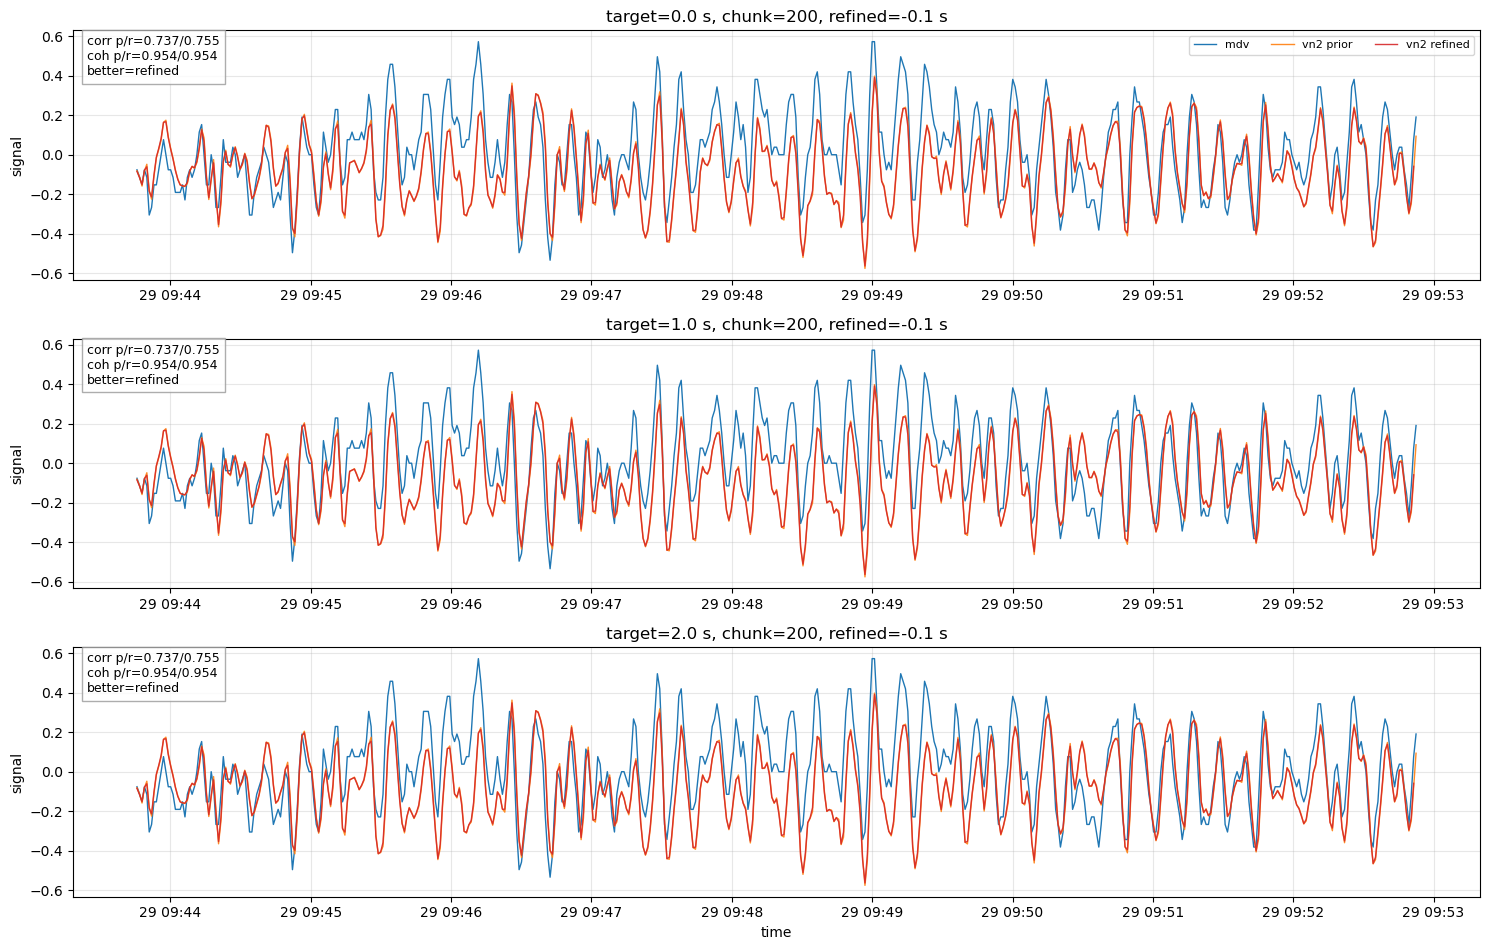

In [8]:
# TEST: prior lidar_offset vs refinement on user-selected chunks.
# Repeatable + flexible:
# - set RUN_COMPARE=true to execute
# - set compare_chunks directly (e.g., [200, 430, 431, 432])
# - set targets_s=nothing to plot those chunks directly
# - set targets_s=[...] to pick nearest chunks by refined offset

function _pearson_finite_local(x, y)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 4 && return NaN
    sx = std(xv)
    sy = std(yv)
    (!isfinite(sx) || !isfinite(sy) || sx == 0 || sy == 0) && return NaN
    return cor(xv, yv)
end

function _coh_5_20s_local(x, y; dt=1.0, flo=1/20, fhi=1/5)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 48 && return NaN

    nseg = min(128, n)
    nseg < 32 && return NaN
    step = max(8, nseg ÷ 2)
    win = 0.5 .- 0.5 .* cos.(2pi .* (0:(nseg - 1)) ./ (nseg - 1))

    nfreq = div(nseg, 2) + 1
    Sxx = zeros(Float64, nfreq)
    Syy = zeros(Float64, nfreq)
    Sxy = zeros(ComplexF64, nfreq)
    k = 0

    for i0 in 1:step:(n - nseg + 1)
        xs = xv[i0:(i0 + nseg - 1)] .- mean(xv[i0:(i0 + nseg - 1)])
        ys = yv[i0:(i0 + nseg - 1)] .- mean(yv[i0:(i0 + nseg - 1)])
        X = FFTW.rfft(xs .* win)
        Y = FFTW.rfft(ys .* win)
        Sxx .+= abs2.(X)
        Syy .+= abs2.(Y)
        Sxy .+= X .* conj.(Y)
        k += 1
    end

    k == 0 && return NaN
    Sxx ./= k
    Syy ./= k
    Sxy ./= k

    coh = abs2.(Sxy) ./ (Sxx .* Syy .+ eps())
    fs = 1 / dt
    freq = collect(0:div(nseg, 2)) .* (fs / nseg)
    band = (freq .>= flo) .& (freq .<= fhi)
    any(band) || return NaN

    c = coh[band]
    c = c[isfinite.(c)]
    isempty(c) && return NaN
    return mean(c)
end

function run_prior_vs_refined_test(run_test::Bool;
    compare_chunks=[200, 430, 431, 432],
    targets_s=nothing,
    ntop=nz,
    sync_corr_thr=0.75,
    sync_coh_thr=0.95,
    fail_corr_thr=0.05,
    fail_coh_thr=0.15)

    if !run_test
        println("Cell prepared. Set RUN_COMPARE = true to execute.")
        return nothing
    end

    chunk_vec = Int.(collect(compare_chunks))

    # Pull priors/finals exactly from pipeline output for these chunks.
    res = process_lidar_vn_data(; mode=:test, test_ic=chunk_vec, ntop=ntop)
    prior_by_ic = Dict(r.ic => r.prior_offset for r in res.seq_results)
    refined_by_ic = Dict(ic => off for (ic, off) in zip(res.seq_ic, Float64.(res.seq_final_native)))

    out = NamedTuple[]
    state = LidarVNSync.init_stream_state()

    for ic in chunk_vec
        win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=ntop, nc_dir="./data/netcdf_stare")
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        prior_s = get(prior_by_ic, ic, NaN)
        refined_s = get(refined_by_ic, ic, NaN)

        vn_prior = LidarVNSync.shift_signal_linear(win.vn2_xcorr, prior_s; dt=dt1)
        vn_refined = LidarVNSync.shift_signal_linear(win.vn2_xcorr, refined_s; dt=dt1)

        corr_prior = _pearson_finite_local(win.mdv, vn_prior)
        corr_refined = _pearson_finite_local(win.mdv, vn_refined)
        coh_prior = _coh_5_20s_local(win.mdv, vn_prior; dt=dt1)
        coh_refined = _coh_5_20s_local(win.mdv, vn_refined; dt=dt1)

        score_prior = (isfinite(corr_prior) ? corr_prior : -Inf) + (isfinite(coh_prior) ? coh_prior : -Inf)
        score_refined = (isfinite(corr_refined) ? corr_refined : -Inf) + (isfinite(coh_refined) ? coh_refined : -Inf)
        better = score_prior > score_refined ? "prior" : (score_refined > score_prior ? "refined" : "tie")

        prior_synced = isfinite(corr_prior) && isfinite(coh_prior) && corr_prior >= sync_corr_thr && coh_prior >= sync_coh_thr
        refined_synced = isfinite(corr_refined) && isfinite(coh_refined) && corr_refined >= sync_corr_thr && coh_refined >= sync_coh_thr
        prior_failed = isfinite(corr_prior) && isfinite(coh_prior) && corr_prior < fail_corr_thr && coh_prior < fail_coh_thr
        refined_failed = isfinite(corr_refined) && isfinite(coh_refined) && corr_refined < fail_corr_thr && coh_refined < fail_coh_thr

        push!(out, (; ic, prior_s, refined_s, corr_prior, corr_refined, coh_prior, coh_refined, prior_synced, refined_synced, prior_failed, refined_failed, better))
    end

    println("chunk,prior_s,refined_s,corr_prior,corr_refined,coh_prior,coh_refined,prior_synced,refined_synced,prior_failed,refined_failed,better")
    for r in out
        println("$(r.ic),$(r.prior_s),$(r.refined_s),$(r.corr_prior),$(r.corr_refined),$(r.coh_prior),$(r.coh_refined),$(r.prior_synced),$(r.refined_synced),$(r.prior_failed),$(r.refined_failed),$(r.better)")
    end

    mkpath("epsilon_data")
    csv_path = joinpath("epsilon_data", "vn_prior_vs_refined_test.csv")
    open(csv_path, "w") do io
        println(io, "chunk,prior_s,refined_s,corr_prior,corr_refined,coh_prior,coh_refined,prior_synced,refined_synced,prior_failed,refined_failed,better")
        for r in out
            println(io, "$(r.ic),$(r.prior_s),$(r.refined_s),$(r.corr_prior),$(r.corr_refined),$(r.coh_prior),$(r.coh_refined),$(r.prior_synced),$(r.refined_synced),$(r.prior_failed),$(r.refined_failed),$(r.better)")
        end
    end
    println("Saved comparison CSV: ", csv_path)

    # Plot selection: direct chunk list when targets_s=nothing, otherwise nearest by refined offset.
    sel_ic = Int[]
    if targets_s === nothing
        sel_ic = copy(chunk_vec)
    else
        refined_vals = [r.refined_s for r in out]
        for t in targets_s
            j = argmin(abs.(refined_vals .- t))
            push!(sel_ic, out[j].ic)
        end
    end

    nplots = length(sel_ic)
    fig, axs = subplots(nplots, 1, figsize=(15, 3.2 * nplots), sharex=false)
    nplots == 1 && (axs = [axs])

    state_plot = LidarVNSync.init_stream_state()
    by_ic = Dict(r.ic => r for r in out)

    for i in 1:nplots
        ic = sel_ic[i]
        row = by_ic[ic]

        win = LidarVNSync.extract_sync_window(beams, Env, state_plot, Vn, UV, ic; ntop=ntop, nc_dir="./data/netcdf_stare")
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        vn_prior = LidarVNSync.shift_signal_linear(win.vn2_xcorr, row.prior_s; dt=dt1)
        vn_refined = LidarVNSync.shift_signal_linear(win.vn2_xcorr, row.refined_s; dt=dt1)

        ax = axs[i]
        ax.plot(win.stare_dt, win.mdv, color="#1f77b4", linewidth=1.0, label="mdv")
        ax.plot(win.stare_dt, vn_prior, color="#ff7f0e", linewidth=1.0, alpha=0.9, label="vn2 prior")
        ax.plot(win.stare_dt, vn_refined, color="#d62728", linewidth=1.0, alpha=0.9, label="vn2 refined")
        ax.grid(true, alpha=0.3)
        ax.set_ylabel("signal")

        ttl = targets_s === nothing ? "chunk=$(ic), prior=$(round(row.prior_s, digits=3)) s, refined=$(round(row.refined_s, digits=3)) s" :
                                      "target=$(round(targets_s[i], digits=1)) s, chunk=$(ic), refined=$(round(row.refined_s, digits=3)) s"
        ax.set_title(ttl)

        txt = "corr p/r=$(round(row.corr_prior, digits=3))/$(round(row.corr_refined, digits=3))\ncoh p/r=$(round(row.coh_prior, digits=3))/$(round(row.coh_refined, digits=3))\nbetter=$(row.better)"
        ax.text(0.01, 0.98, txt, transform=ax.transAxes, va="top", ha="left", bbox=Dict("facecolor"=>"white", "alpha"=>0.8, "edgecolor"=>"0.6"), fontsize=9)

        if i == 1
            ax.legend(loc="upper right", ncol=3, fontsize=8)
        end
        if i == nplots
            ax.set_xlabel("time")
        end
    end

    tight_layout()
    fig_path = joinpath("epsilon_data", "vn_prior_vs_refined_examples.png")
    savefig(fig_path, dpi=150, bbox_inches="tight")
    println("Saved figure: ", fig_path)

    return (; rows=out, fig, csv_path, fig_path)
end

# prior_vs_refined_result = run_prior_vs_refined_test(true; compare_chunks=[200, 430, 431, 432], targets_s=nothing, ntop=nz)
prior_vs_refined_result = run_prior_vs_refined_test(true; compare_chunks=200:210, targets_s=[0,1,2], ntop=nz)

if !isnothing(prior_vs_refined_result)
    prior_vs_refined_result.fig
end

In [4]:
# WHAT-IF TEST: chunks 430:432 with normal prior vs forced prior_s = 0
# Reports correlation/coherence and final refined offsets for both paths.
# NOTE: normal prior is now taken from a context run (not just the local chunk subset),
# so it should agree with earlier sequential tests.

RUN_WHATIF = true

if !RUN_WHATIF
    println("Cell prepared. Set RUN_WHATIF = true to execute.")
else
    function pearson_finite_local(x, y)
        xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
        n = length(xv)
        n < 4 && return NaN
        sx = std(xv)
        sy = std(yv)
        (!isfinite(sx) || !isfinite(sy) || sx == 0 || sy == 0) && return NaN
        return cor(xv, yv)
    end

    function coh_5_20s_local(x, y; dt=1.0, flo=1/20, fhi=1/5)
        xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
        n = length(xv)
        n < 48 && return NaN

        nseg = min(128, n)
        nseg < 32 && return NaN
        step = max(8, nseg ÷ 2)
        win = 0.5 .- 0.5 .* cos.(2pi .* (0:(nseg - 1)) ./ (nseg - 1))

        nfreq = div(nseg, 2) + 1
        Sxx = zeros(Float64, nfreq)
        Syy = zeros(Float64, nfreq)
        Sxy = zeros(ComplexF64, nfreq)
        k = 0

        for i0 in 1:step:(n - nseg + 1)
            xs = xv[i0:(i0 + nseg - 1)] .- mean(xv[i0:(i0 + nseg - 1)])
            ys = yv[i0:(i0 + nseg - 1)] .- mean(yv[i0:(i0 + nseg - 1)])
            X = FFTW.rfft(xs .* win)
            Y = FFTW.rfft(ys .* win)
            Sxx .+= abs2.(X)
            Syy .+= abs2.(Y)
            Sxy .+= X .* conj.(Y)
            k += 1
        end

        k == 0 && return NaN
        Sxx ./= k
        Syy ./= k
        Sxy ./= k

        coh = abs2.(Sxy) ./ (Sxx .* Syy .+ eps())
        fs = 1 / dt
        freq = collect(0:div(nseg, 2)) .* (fs / nseg)
        band = (freq .>= flo) .& (freq .<= fhi)
        any(band) || return NaN

        c = coh[band]
        c = c[isfinite.(c)]
        isempty(c) && return NaN
        return mean(c)
    end

    chunks = [430, 431, 432]

    # Use a context run to recover the same sequential prior behavior as broader tests.
    prior_context = 200:maximum(chunks)
    context_res = process_lidar_vn_data(; mode=:test, test_ic=collect(prior_context), ntop=nz)
    prior_by_ic = Dict(r.ic => r.prior_offset for r in context_res.seq_results)

    println("Prior source context: $(first(prior_context)):$(last(prior_context))")

    results = NamedTuple[]
    state = LidarVNSync.init_stream_state()

    println("chunk,prior_mode,prior_s,final_refined_s,corr,coh_5_20s")
    for ic in chunks
        win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        # Path A: normal pipeline prior from context run
        p_norm = get(prior_by_ic, ic, NaN)
        s_norm = LidarVNSync.coarse_and_fine_lag(win.mdv, win.vn2_xcorr; prior_seconds=p_norm)
        r_norm = LidarVNSync.refine_offset_20hz(win, s_norm, Vn)
        final_norm = p_norm + r_norm.final_offset_native
        vn_norm = LidarVNSync.shift_signal_linear(win.vn2_xcorr, final_norm; dt=dt1)
        corr_norm = pearson_finite_local(win.mdv, vn_norm)
        coh_norm = coh_5_20s_local(win.mdv, vn_norm; dt=dt1)
        println("$(ic),normal,$(p_norm),$(final_norm),$(corr_norm),$(coh_norm)")
        push!(results, (; ic, mode="normal", prior_s=p_norm, final_refined_s=final_norm, corr=corr_norm, coh_5_20s=coh_norm))

        # Path B: forced prior_s = 0
        p_zero = 0.0
        s_zero = LidarVNSync.coarse_and_fine_lag(win.mdv, win.vn2_xcorr; prior_seconds=p_zero)
        r_zero = LidarVNSync.refine_offset_20hz(win, s_zero, Vn)
        final_zero = p_zero + r_zero.final_offset_native
        vn_zero = LidarVNSync.shift_signal_linear(win.vn2_xcorr, final_zero; dt=dt1)
        corr_zero = pearson_finite_local(win.mdv, vn_zero)
        coh_zero = coh_5_20s_local(win.mdv, vn_zero; dt=dt1)
        println("$(ic),forced_zero,$(p_zero),$(final_zero),$(corr_zero),$(coh_zero)")
        push!(results, (; ic, mode="forced_zero", prior_s=p_zero, final_refined_s=final_zero, corr=corr_zero, coh_5_20s=coh_zero))
    end

    mkpath("epsilon_data")
    out_csv = joinpath("epsilon_data", "vn_whatif_prior_zero_430_432.csv")
    open(out_csv, "w") do io
        println(io, "chunk,prior_mode,prior_s,final_refined_s,corr,coh_5_20s")
        for r in results
            println(io, "$(r.ic),$(r.mode),$(r.prior_s),$(r.final_refined_s),$(r.corr),$(r.coh_5_20s)")
        end
    end
    println("Saved what-if CSV: ", out_csv)

    results
end

Prior source context: 200:432
chunk,prior_mode,prior_s,final_refined_s,corr,coh_5_20s
430,normal,0.0,1.0,0.021948944541197092,0.15357023005613843
430,forced_zero,0.0,1.0,0.021948944541197092,0.15357023005613843
431,normal,8.16,9.16,0.05257279117977418,0.16578151126923735
431,forced_zero,0.0,0.9500000000000001,-0.0005654109087810328,0.15899318723141337
432,normal,9.070714285714287,10.070714285714287,0.0235015976672206,0.1409739260455958
432,forced_zero,0.0,-0.30000000000000004,0.08035181285886527,0.15085680107823232
Saved what-if CSV: epsilon_data/vn_whatif_prior_zero_430_432.csv


6-element Vector{NamedTuple}:
 (ic = 430, mode = "normal", prior_s = 0.0, final_refined_s = 1.0, corr = 0.021948944541197092, coh_5_20s = 0.15357023005613843)
 (ic = 430, mode = "forced_zero", prior_s = 0.0, final_refined_s = 1.0, corr = 0.021948944541197092, coh_5_20s = 0.15357023005613843)
 (ic = 431, mode = "normal", prior_s = 8.16, final_refined_s = 9.16, corr = 0.05257279117977418, coh_5_20s = 0.16578151126923735)
 (ic = 431, mode = "forced_zero", prior_s = 0.0, final_refined_s = 0.9500000000000001, corr = -0.0005654109087810328, coh_5_20s = 0.15899318723141337)
 (ic = 432, mode = "normal", prior_s = 9.070714285714287, final_refined_s = 10.070714285714287, corr = 0.0235015976672206, coh_5_20s = 0.1409739260455958)
 (ic = 432, mode = "forced_zero", prior_s = 0.0, final_refined_s = -0.30000000000000004, corr = 0.08035181285886527, coh_5_20s = 0.15085680107823232)

In [ ]:
# 1) process test data and compute offsets
# sync_result_test = process_lidar_vn_data(; mode=:test, test_ic=175:190, ntop=nz)

# @printf("processed chunks: %d\n", length(sync_result_test.seq_ic))
# @printf("20 Hz offsets (ms): %s\n", string(sync_result_test.seq_final_native_ms))
# @printf("20 Hz jumps (ms):   %s\n", string(sync_result_test.seq_jump_20hz_ms))

processed chunks: 16
20 Hz offsets (ms): [-100, -100, -50, -100, -100, -150, -50, -50, 0, 50, 0, 0, 0, 0, 0, 50]
20 Hz jumps (ms):   [0, 0, 50, -50, 0, -50, 100, 0, 50, 50, -50, 0, 0, 0, 0, 50]


In [ ]:
# 2) save test result as NetCDF
# nc_out = save_sync_data_netcdf(sync_result_test; nc_out=joinpath("epsilon_data", "vn_sync_offsets.nc"))
# println("Saved: ", nc_out)

# # quick schema check
# run(`ncdump -h $nc_out`)

Saved: epsilon_data/vn_sync_offsets.nc
netcdf vn_sync_offsets {
dimensions:
	chunk = 16 ;
	record = 8535 ;
variables:
	int chunk_index(chunk) ;
	int chunk_n_records(chunk) ;
	int chunk_record_start_idx(chunk) ;
	int chunk_record_end_idx(chunk) ;
	int64 chunk_start_epoch_ms(chunk) ;
		chunk_start_epoch_ms:long_name = "chunk start time in epoch milliseconds since 1970-01-01" ;
	int64 chunk_end_epoch_ms(chunk) ;
		chunk_end_epoch_ms:long_name = "chunk end time in epoch milliseconds since 1970-01-01" ;
	int64 offset_20hz_ms(chunk) ;
		offset_20hz_ms:units = "milliseconds" ;
		offset_20hz_ms:long_name = "final synchronization offset from 20 Hz native refinement" ;
	int64 jump_20hz_ms(chunk) ;
		jump_20hz_ms:units = "milliseconds" ;
		jump_20hz_ms:long_name = "chunk-to-chunk jump in 20 Hz native offset (current minus previous)" ;
	int64 time(record) ;
		time:units = "milliseconds since 2024-04-29T00:00:00 UTC" ;
		time:calendar = "standard" ;
		time:standard_name = "time" ;
		time:axis = "T"

Process(`ncdump -h epsilon_data/vn_sync_offsets.nc`, ProcessExited(0))

dopplervel   size=(518, 80)      missing= 22335 finite= 19105 nan=     0
intensity    size=(518, 80)      missing=     0 finite= 41440 nan=     0
Ur           size=(518, 80)      missing=     0 finite= 41440 nan=     0
Vr           size=(518, 80)      missing=     0 finite= 41440 nan=     0
clock prior applied: 149330 milliseconds
coarse offset after iterative envelope passes = 0.000 s
fine residual after coarse shift = -1.020 s
final offset (1 Hz stage) = -1.020 s
final offset (20 Hz raw) = -0.050 s
final offset (20 Hz native step) = -0.050 s [step=0.050]


sys:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.


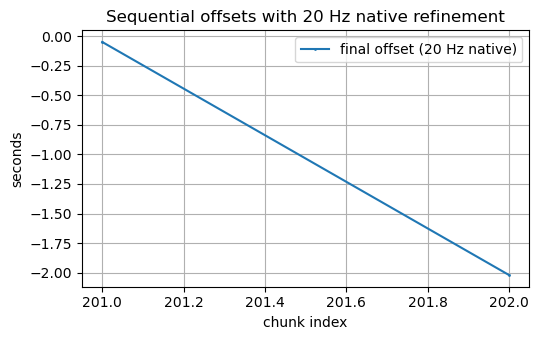

In [10]:
# 3) run diagnostics
# mode=:test shows both sequential offsets and one single-window diagnostic
sync_result_test = process_lidar_vn_data(; mode=:test, test_ic=201:202, ntop=nz)
diag_test = run_sync_diagnostics(sync_result_test; mode=:test, ntop=nz)

diag_test.fig_offsets
# diag_test.fig_single

Schema verified for test run: (:seq_results, :seq_ref20, :seq_ic, :seq_prior, :seq_coarse, :seq_final, :seq_final_native, :seq_final_native_ms, :seq_jump_20hz_ms, :seq_fine, :seq_jump_candidate, :seq_jump_accepted, :chunk_lens, :chunk_record_starts, :chunk_record_ends, :nrec)
Uncomment below to run full production processing with the same schema.
Saved full-record output: epsilon_data/vn_sync_offsets_all.nc


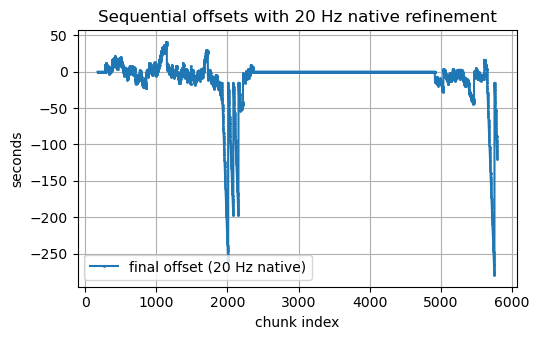

In [ ]:
# Process VN offsets for the full lidar record
expected_schema = (
    :seq_results,
    :seq_ref20,
    :seq_ic,
    :seq_prior,
    :seq_coarse,
    :seq_final,
    :seq_final_native,
    :seq_final_native_ms,
    :seq_jump_20hz_ms,
    :seq_fine,
    :seq_jump_candidate,
    :seq_jump_accepted,
    :chunk_lens,
    :chunk_record_starts,
    :chunk_record_ends,
    :nrec,
)

@assert propertynames(sync_result_test) == expected_schema
println("Schema verified for test run: ", expected_schema)
println("Uncomment below to run full production processing with the same schema.")

# sync_result_all = process_lidar_vn_data(; mode=:all, ntop=nz) # takes ~ 2h
# @assert propertynames(sync_result_all) == expected_schema
# nc_out_all = save_sync_data_netcdf(sync_result_all; nc_out=joinpath("epsilon_data", "vn_sync_offsets_all.nc"))
diag_all = run_sync_diagnostics(sync_result_all; mode=:all, ntop=nz)
println("Saved full-record output: ", nc_out_all)

Using offsets file: epsilon_data/vn_sync_offsets_all.nc
Selected lag examples (target_s, ic, actual_s, abs_error_s):
(0.0, 183, 0.0, 0.0)
(-10.0, 601, -10.0, 0.0)
(-30.0, 5400, -29.9, 0.10000000000000142)
(-60.0, 1937, -60.4, 0.3999999999999986)
(-120.0, 2052, -119.45, 0.5499999999999972)
(-180.0, 2075, -179.65, 0.3499999999999943)


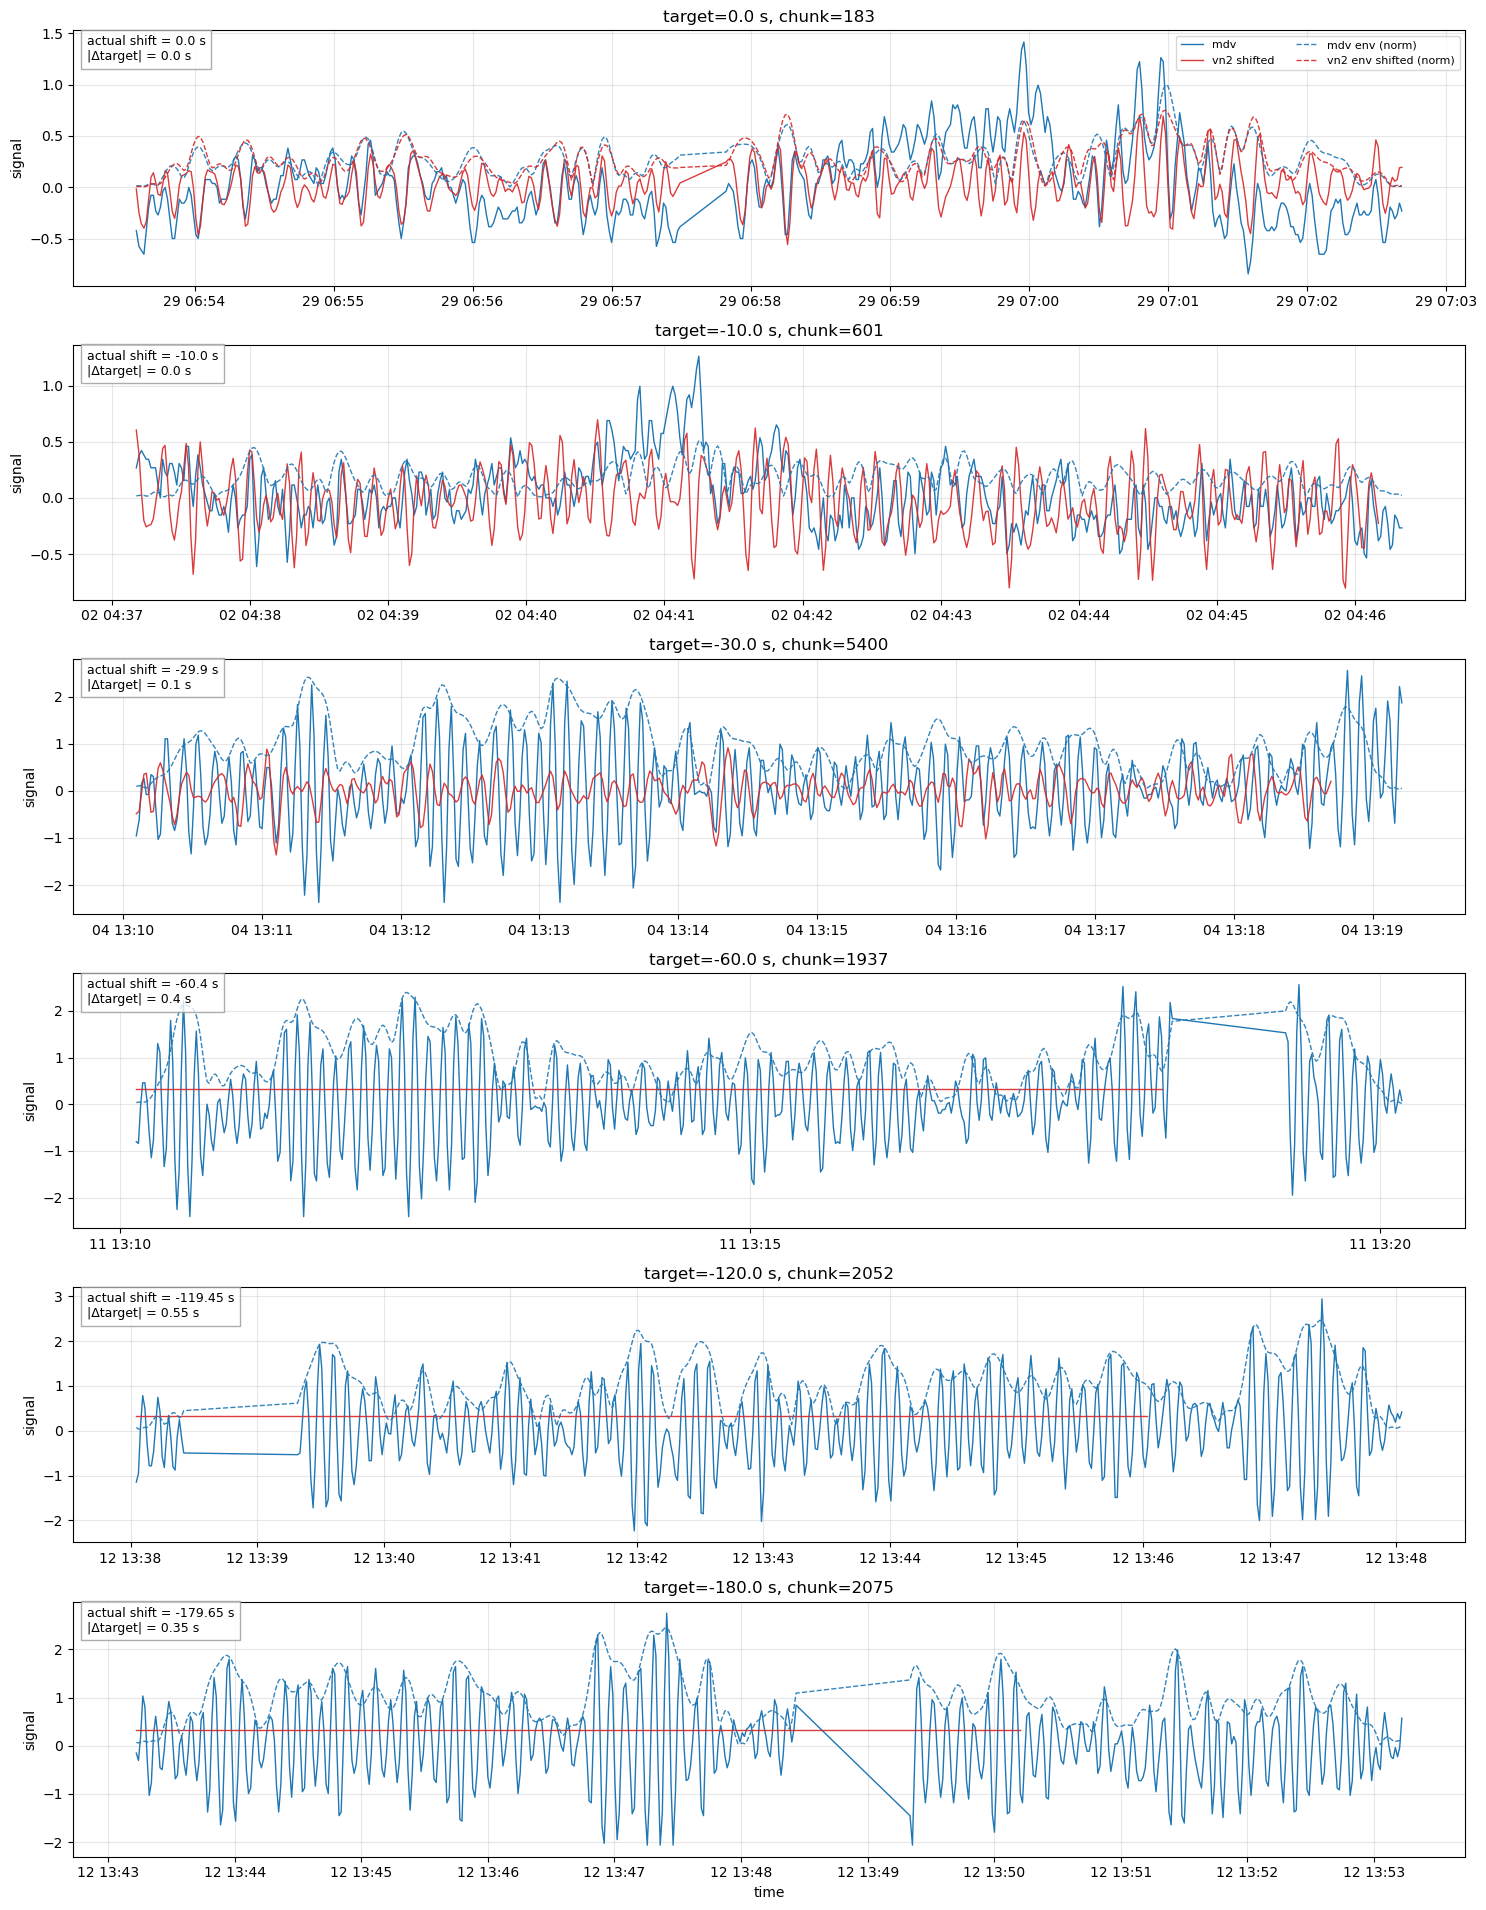

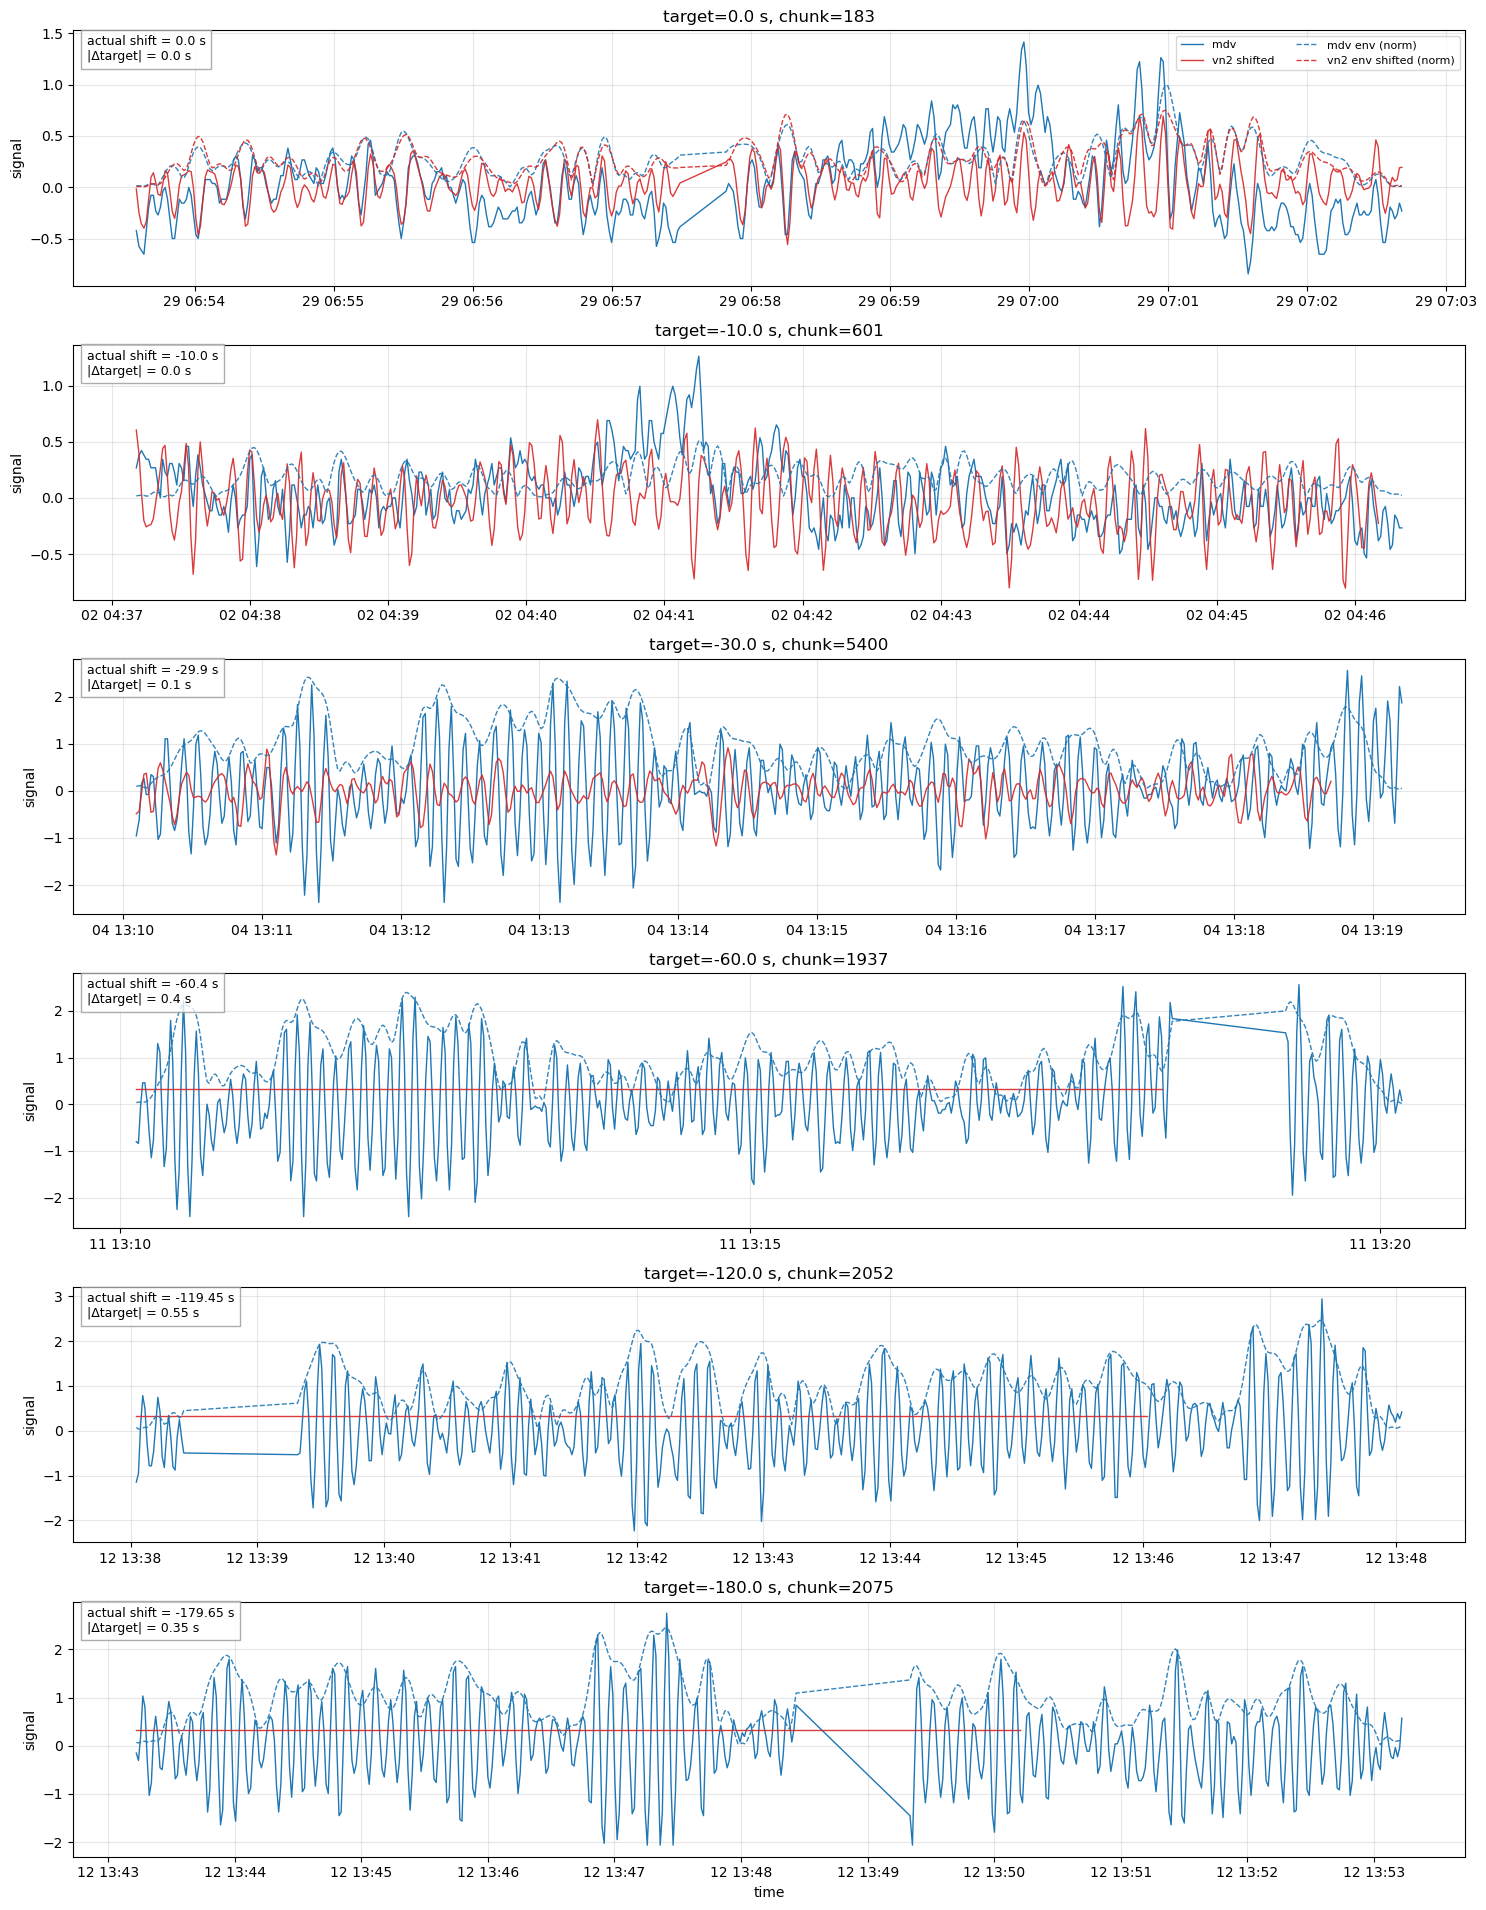

In [ ]:
# 8) verify lag examples at target LARGE negative shifts (seconds)

targets_s = [0.0, -10.0, -30.0, -60.0, -120.0, -180.0]
nc_candidates = [
    joinpath("epsilon_data", "vn_sync_offsets_all.nc"),
    joinpath("epsilon_data", "vn_sync_offsets.nc"),
]
nc_path = findfirst(isfile, nc_candidates)
isnothing(nc_path) && error("No vn_sync_offsets NetCDF found in epsilon_data/.")
nc_path = nc_candidates[nc_path]
println("Using offsets file: ", nc_path)

ds = NCDataset(nc_path, "r")
chunk_idx = Int.(ds["chunk_index"][:])
offset_ms = Float64.(ds["offset_20hz_ms"][:])
close(ds)

valid = isfinite.(offset_ms) .& (offset_ms .!= -9_999_000)
chunk_idx = chunk_idx[valid]
offset_s = offset_ms[valid] ./ 1000

pick = [argmin(abs.(offset_s .- t)) for t in targets_s]
example_ic = chunk_idx[pick]
example_shift_s = offset_s[pick]
example_abs_err_s = abs.(example_shift_s .- targets_s)

println("Selected lag examples (target_s, ic, actual_s, abs_error_s):")
for i in eachindex(targets_s)
    println((targets_s[i], example_ic[i], example_shift_s[i], example_abs_err_s[i]))
end

# Build sync context and pull each selected chunk.
ctx = LidarVNSync.setup_sync_context()
Env = ctx.Env
Vn = ctx.Vn
UV = ctx.UV
beams = ctx.beams
state = LidarVNSync.init_stream_state()

fig, axs = subplots(length(targets_s), 1, figsize=(15, 3.2 * length(targets_s)), sharex=false)
length(targets_s) == 1 && (axs = [axs])

for i in eachindex(targets_s)
    ic = example_ic[i]
    t_target = targets_s[i]
    t_shift = example_shift_s[i]
    t_err = example_abs_err_s[i]

    win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=ctx.nz, nc_dir="./data/netcdf_stare")
    dt1 = LidarVNSync.dt_seconds(win.stare_dt)
    (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

    # Shift VN by selected offset and compare against mdv in the same panel.
    vn2_sync = LidarVNSync.shift_signal_linear(win.vn2, t_shift; dt=dt1)

    mdv_bp = LidarVNSync.fft_bandpass(win.mdv; dt=dt1)
    vn2_bp = LidarVNSync.fft_bandpass(vn2_sync; dt=dt1)
    mdv_env = LidarVNSync.analytic_envelope_fft(mdv_bp)
    vn2_env = LidarVNSync.analytic_envelope_fft(vn2_bp)

    # Normalize envelopes so both time series and envelopes are readable on one axis.
    finite_env = isfinite.(mdv_env) .& isfinite.(vn2_env)
    env_scale = any(finite_env) ? maximum(abs, vcat(mdv_env[finite_env], vn2_env[finite_env])) : 1.0
    env_scale == 0 && (env_scale = 1.0)
    mdv_env_n = mdv_env ./ env_scale
    vn2_env_n = vn2_env ./ env_scale

    ax = axs[i]
    ax.plot(win.stare_dt, win.mdv, color="#1f77b4", linewidth=1.0, label="mdv")
    ax.plot(win.stare_dt, vn2_sync, color="#d62728", linewidth=1.0, alpha=0.9, label="vn2 shifted")
    ax.plot(win.stare_dt, mdv_env_n, color="#1f77b4", linestyle="--", linewidth=1.0, alpha=0.9, label="mdv env (norm)")
    ax.plot(win.stare_dt, vn2_env_n, color="#d62728", linestyle="--", linewidth=1.0, alpha=0.9, label="vn2 env shifted (norm)")
    ax.grid(true, alpha=0.3)
    ax.set_ylabel("signal")
    ax.set_title("target=$(round(t_target, digits=1)) s, chunk=$(ic)")

    txt = "actual shift = $(round(t_shift, digits=3)) s\n|Δtarget| = $(round(t_err, digits=3)) s"
    ax.text(0.01, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
            bbox=Dict("facecolor"=>"white", "alpha"=>0.8, "edgecolor"=>"0.6"), fontsize=9)

    if i == 1
        ax.legend(loc="upper right", ncol=2, fontsize=8)
    end
    if i == length(targets_s)
        ax.set_xlabel("time")
    end
end

tight_layout()
fig

## Next Steps

The notebook is now organized around a module-based workflow:

- Cell 2: preamble and context setup from `lidar_vn_sync.jl`
- Cell 3: workflow wrapper functions
- Cell 4: process test interval and compute 20 Hz offsets/jumps
- Cell 5: save NetCDF output
- Cell 6: run diagnostics
- Cell 7: full-record processing template

Planned follow-up:

- run the full-record cell and save `vn_sync_offsets_all.nc`
- review jump behavior over the full record using 20 Hz millisecond jumps
- add any quality-control flags needed for production

### Offset Bookkeeping Note

The timing solution is now treated as:

- **prior offset**: the coarse offset already believed from previous chunks (or initialization)
- **refinement offset**: the new residual found in the current window
- **final offset**: `prior + refinement`

VectorNav window selection for refinement is anchored by the prior offset first, then the refinement is estimated and added.

If `lidar_clock_fast_by` is biased, correcting that term should improve the residual refinement behavior because the refinement stage is now explicitly layered on top of the prior rather than replacing it.